In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
from tensorflow.keras.datasets import cifar10

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 27s 0us/step


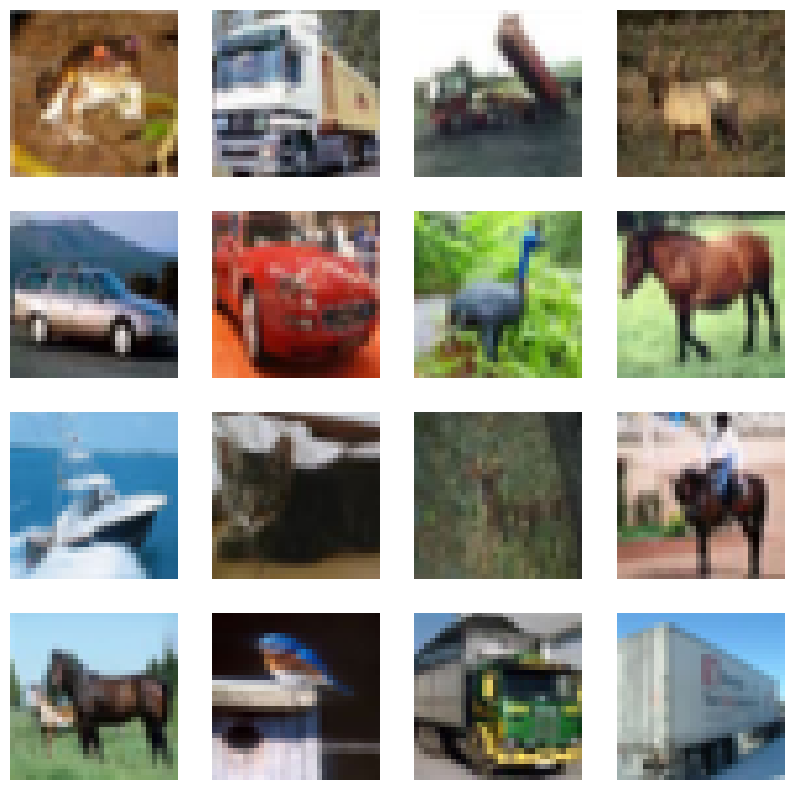

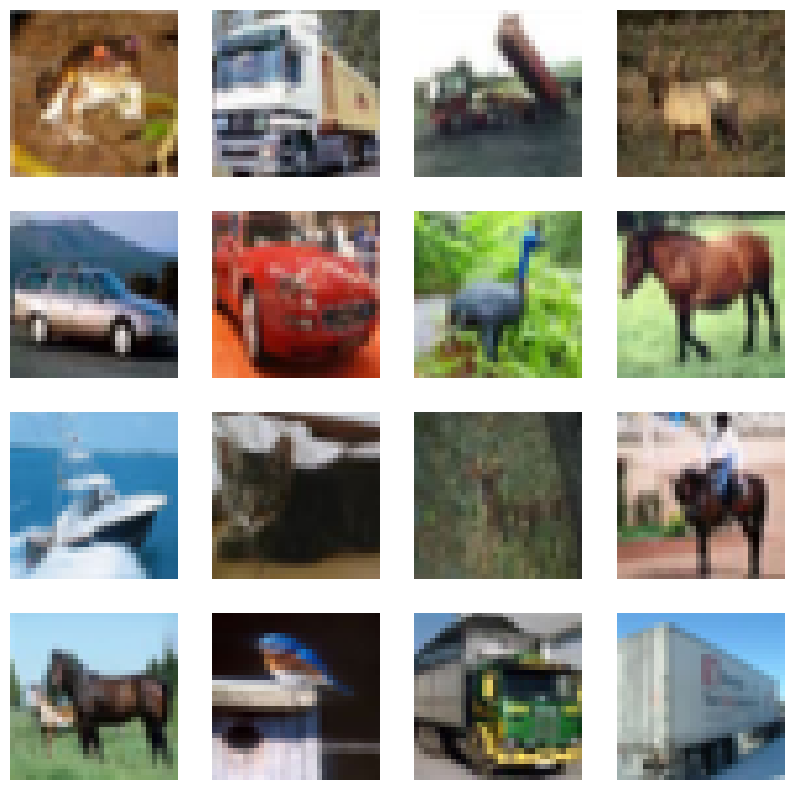

In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

plt.figure(figsize=(10, 10))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_train[i])
    plt.axis('off')

plt.show(())

In [4]:
from PIL import Image, ImageDraw

image = Image.new('RGB', (224, 224), color = (225, 255, 255) )

draw = ImageDraw.Draw(image)
draw.rectangle([(50, 50), (174, 174)], fill=(255, 0, 0))

image.save('sample.jpg')

In [6]:
img_path = 'sample.jpg'
img = load_img(img_path)
x = img_to_array(img)
x = np.expand_dims(x, axis=0)

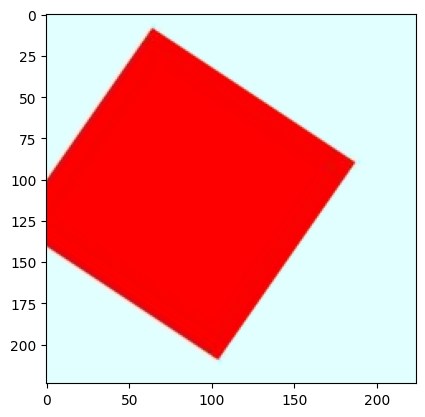

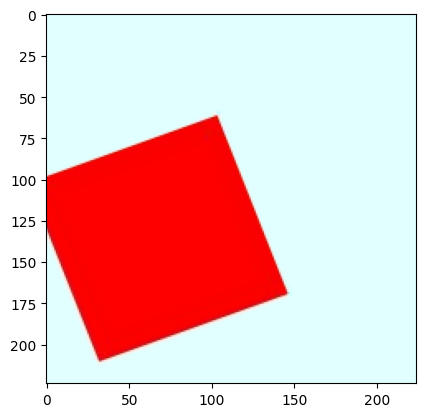

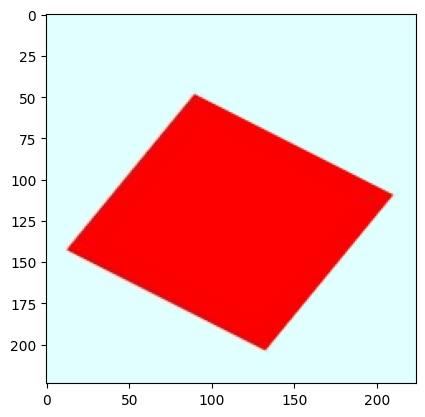

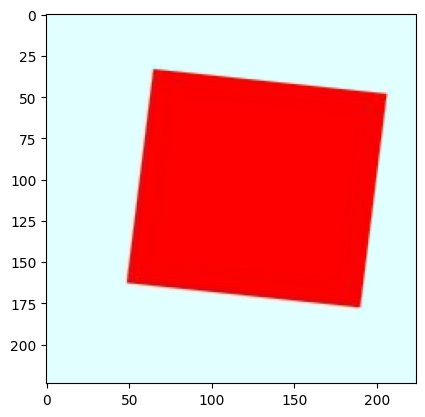

In [7]:
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break

plt.show()

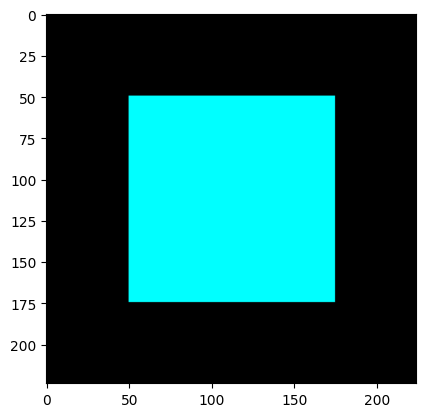

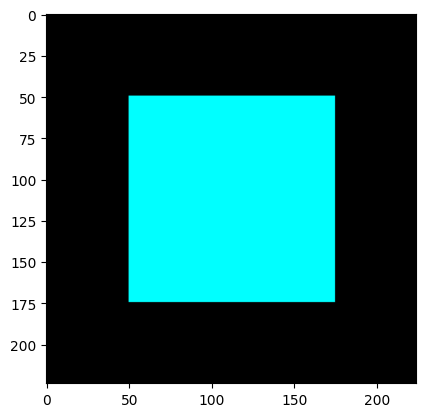

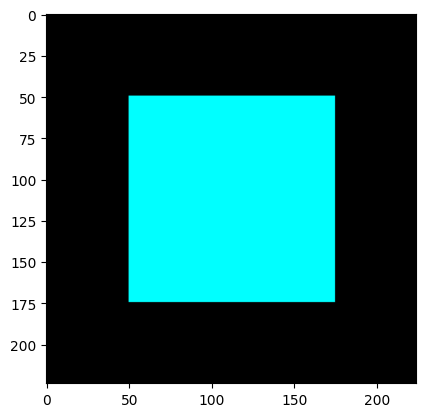

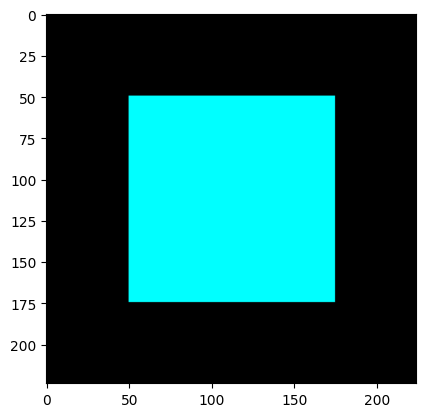

In [10]:
datagen = ImageDataGenerator(
    # featurewise_center=True,
    # featurewise_std_normalization=True,
    samplewise_center=True,
    samplewise_std_normalization=True
)

datagen.fit(x)

i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break

plt.show()

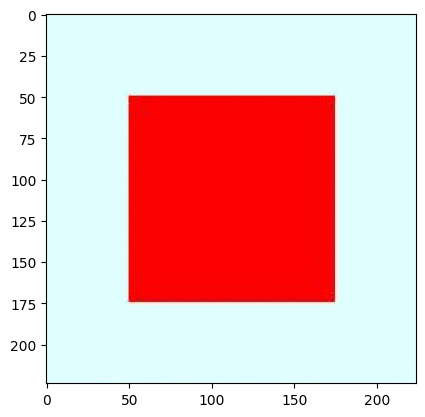

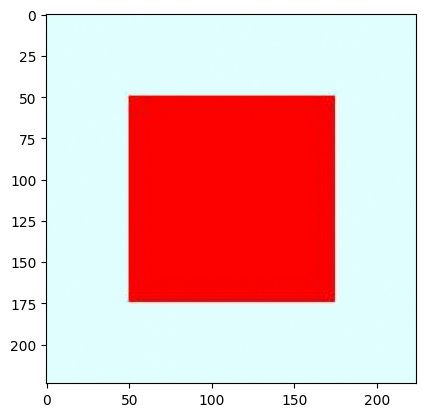

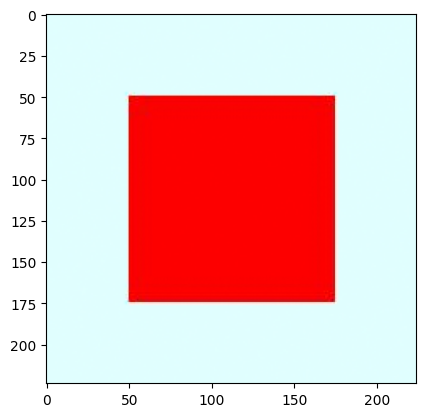

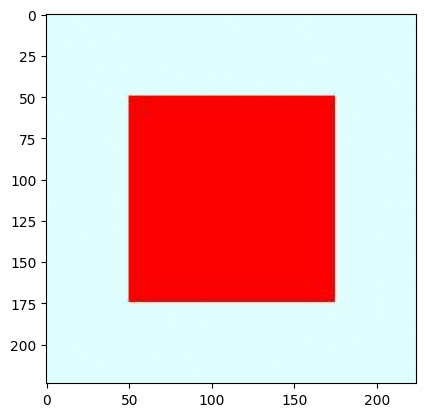

In [12]:
# custom data augmentation function

def add_random_noise(image):
    noise = np.random.normal(0, 0.1, image.shape)
    return image + noise

datagen = ImageDataGenerator(preprocessing_function=add_random_noise)

i = 0

for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break

plt.show()

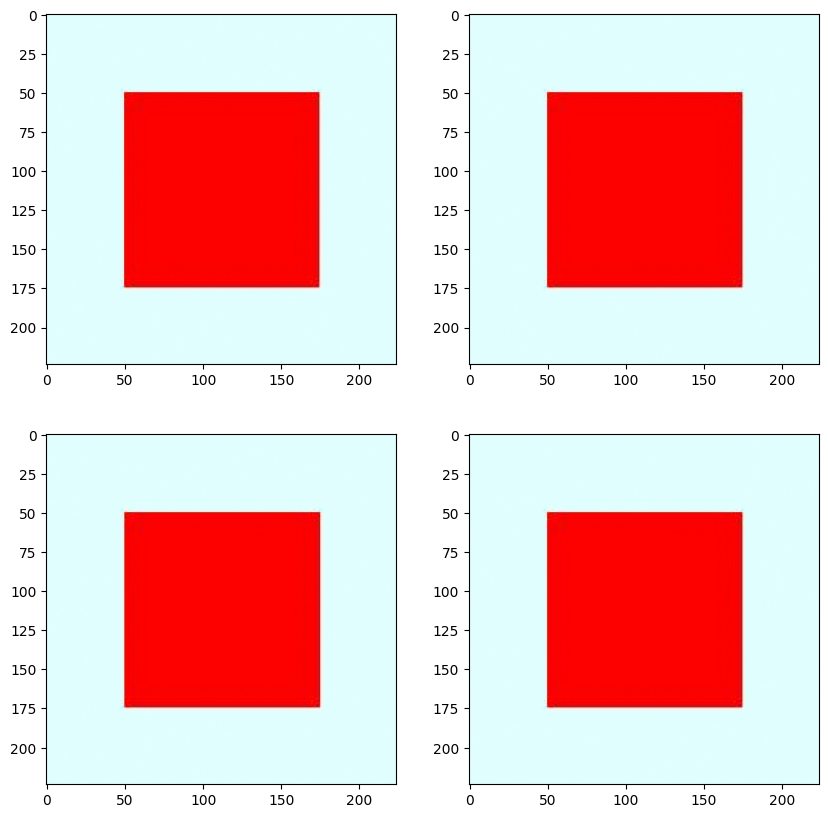

In [13]:
plt.figure(figsize=(10, 10))
for i, batch in enumerate(datagen.flow(x, batch_size=1)):
    if i >= 4:
        break
    plt.subplot(2, 2, i+1)
    plt.imshow(batch[0].astype('uint8'))
plt.show()

In [15]:
import urllib.request

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/RgP3JFNtPTZA34UmG3KZaA/sample-images.zip"
urllib.request.urlretrieve(url, "sample_images.zip")

('sample_images.zip', <http.client.HTTPMessage at 0x23f67b43590>)

In [16]:
import zipfile
with zipfile.ZipFile("sample_images.zip", "r") as zip_ref:
    zip_ref.extractall("sample_images")

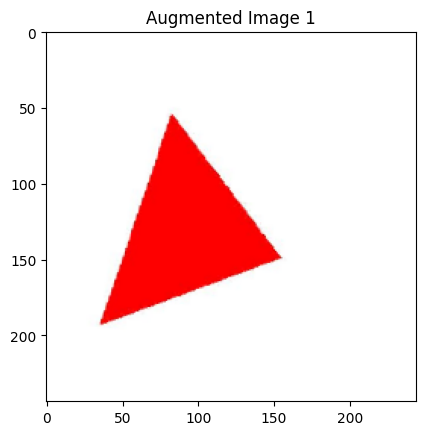

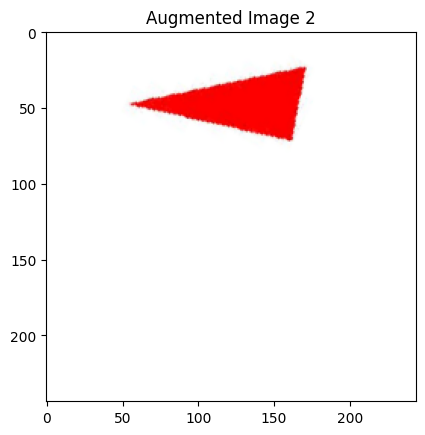

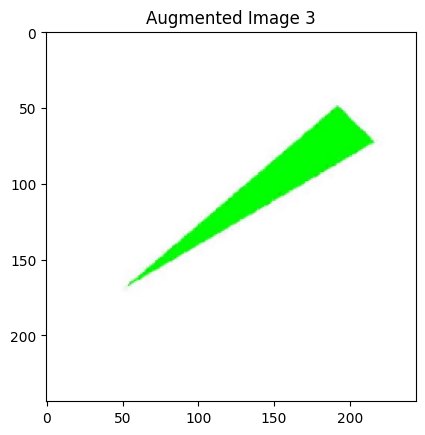

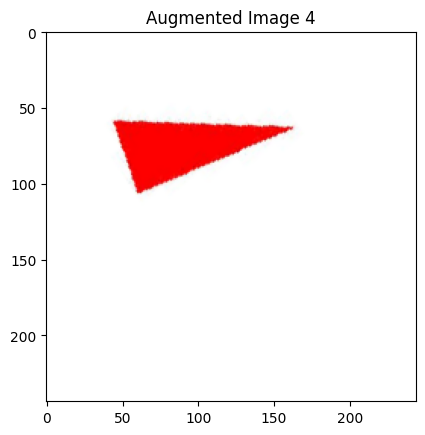

In [18]:
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

image_paths = [
    "sample_images/sample_images/training_images1.jpg",
    "sample_images/sample_images/training_images2.jpg",
    "sample_images/sample_images/training_images3.jpg",
]

training_images = []

for image_path in image_paths:
    img = load_img(image_path, target_size=(244, 244))
    img_array = img_to_array(img)
    training_images.append((img_array))

training_images = np.array(training_images)

i = 0

for batch in datagen.flow(training_images, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(array_to_img(batch[0]))
    plt.title(f"Augmented Image {i + 1}")
    i += 1
    if i % 4 == 0:
        break

plt.show()

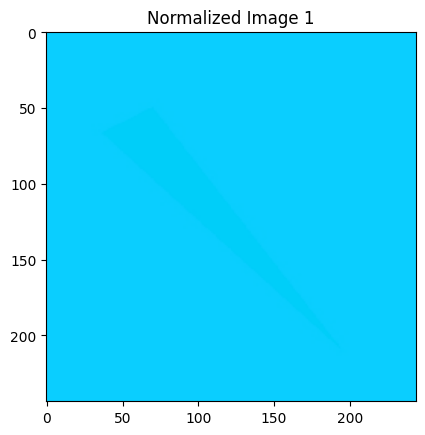

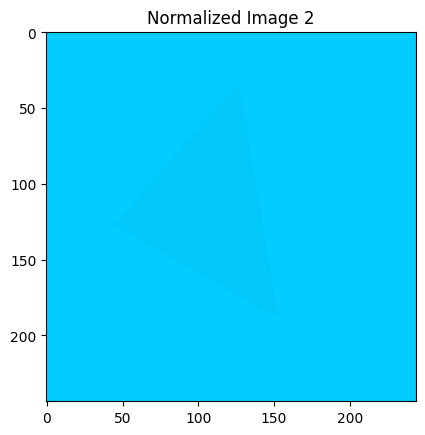

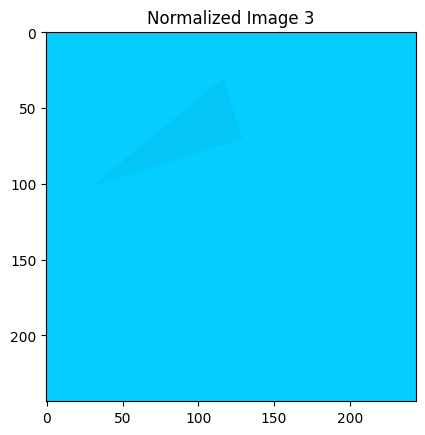

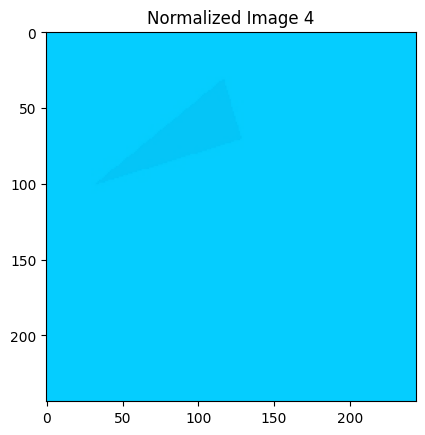

In [19]:
datagen = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    samplewise_center=True,
    samplewise_std_normalization=True
)

datagen.fit(training_images)

i = 0

for batch in datagen.flow(training_images, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(array_to_img(batch[0]))
    plt.title(f"Normalized Image {i + 1}")
    i += 1
    if i % 4 == 0:
        break

plt.show()

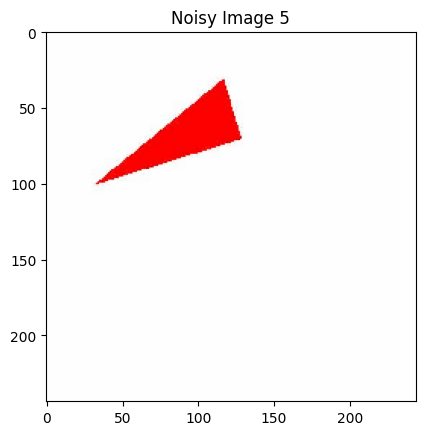

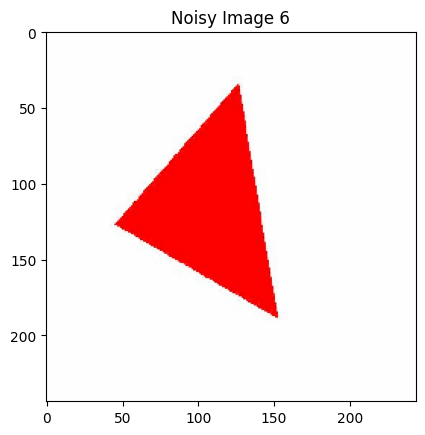

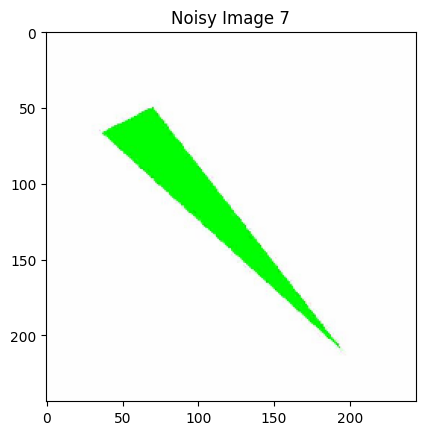

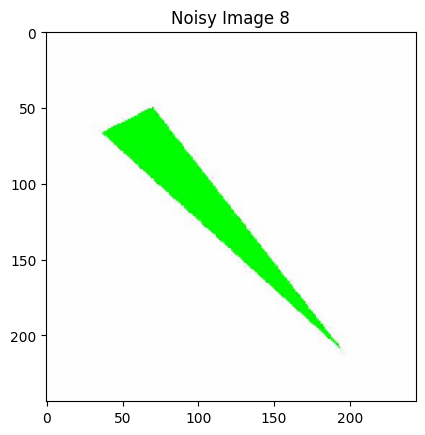

In [20]:
def add_random_noise(image):
    noise = np.random.normal(0, 0.1, image.shape)
    return image + noise

datagen = ImageDataGenerator(preprocessing_function=add_random_noise)

for batch in datagen.flow(training_images, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(array_to_img(batch[0]))
    plt.title(f"Noisy Image {i + 1}")

    i += 1
    if i % 4 == 0:
        break

plt.show()